# Análisis exploratorio

### 1) importaciones, lecturas y merges

In [2]:
import os
import pathlib
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import seaborn as sns
import pandas as pd
import networkx as nx

In [23]:
QA_dir = '../QA'
entity_dir = '../Datasets'
QA_df = pd.read_csv(os.path.join(QA_dir, "golden_QA_dataset.csv"))

# Cargamos los tipos de entidad
folder_entity_types = os.path.join(entity_dir, "entity_types_clean")
files_entity_types = os.listdir(folder_entity_types)
roots_entitity_type = [os.path.join(folder_entity_types, file) for file in files_entity_types if file.endswith('.csv')]
entity_types_dfs = {files_entity_types[i].split(".")[0]: pd.read_csv(roots_entitity_type[i]) for i in range(len(roots_entitity_type))}
big_entity_types_df = pd.concat(entity_types_dfs.values(), ignore_index=True)
big_entity_types_df = big_entity_types_df.drop_duplicates(subset=['entidad', 'tipo_entidad'])

# Cruzamos los tipos de entidades con las tripletas
merged_df = QA_df.merge(
    big_entity_types_df,
    left_on='entidad',
    right_on='entidad',
    how='left'
)

merged_df['obtenido_de'] = merged_df['obtenido_de'].apply(lambda x: eval(x)[0] if pd.notnull(x) else x)

# Separamos los dataframes por país y tipo de entidad
entidades_humanas = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]
entidades_no_humanas = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]

conteo_humanos_por_pais = entidades_humanas.groupby('obtenido_de')['entidad'].nunique().reset_index()
conteo_no_humanos_por_pais = entidades_no_humanas.groupby('obtenido_de')['entidad'].nunique().reset_index()

In [27]:
humans = merged_df[merged_df['tipo_entidad'] == "ser humano".strip()]
non_humans = merged_df[merged_df['tipo_entidad'] != "ser humano".strip()]
prop = len(humans) / len(merged_df)
print(f"Proporción de tripletas con entidades personas: {prop:.2%} ({len(humans)} de {len(merged_df)})")
print(f'Es decir, hay {len(humans)} tripletas para entidades personas y {len(non_humans)} para entidades no personas.')

Proporción de tripletas con entidades personas: 87.65% (42931 de 48982)
Es decir, hay 42931 tripletas para entidades personas y 6051 para entidades no personas.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(conteo_humanos_por_pais['obtenido_de'],
            conteo_humanos_por_pais['entidad'],
            color="#4C72B0")
axes[0].set_title("Cantidad de entidades 'ser humano' por país")
axes[0].set_ylabel("Número de tripletas")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(conteo_no_humanos_por_pais['obtenido_de'],
            conteo_no_humanos_por_pais['entidad'],
            color="#55A868")
axes[1].set_title("Cantidad de entidades diferentes a 'ser humano' por país")
axes[1].set_ylabel("Número de tripletas")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' on line 10 (3190350543.py, line 11)

### 2) Relaciones más frecuentes para entidades (personas y objetos)

In [7]:
def plot_relations(data, top_n=15, title_suffix='ser humano'):
    plt.figure(figsize=(16, 9))
    sns.barplot(
        data=data.head(top_n),
        y='relacion',
        x='count',
        hue='relacion',
        palette='viridis',
        legend=False
    )
    plt.xlabel('Frecuencia')
    plt.ylabel('Relación')
    plt.title(f'Top {top_n} relaciones más frecuentes para {title_suffix}')
    plt.tight_layout()
    plt.show()

['ciudadania', 'ocupacion', 'fecha de nacimiento', 'lugar de nacimiento', 'fecha de defuncion', 'educado en', 'cargo', 'premio recibido', 'empleador', 'miembro de', 'obra notable']


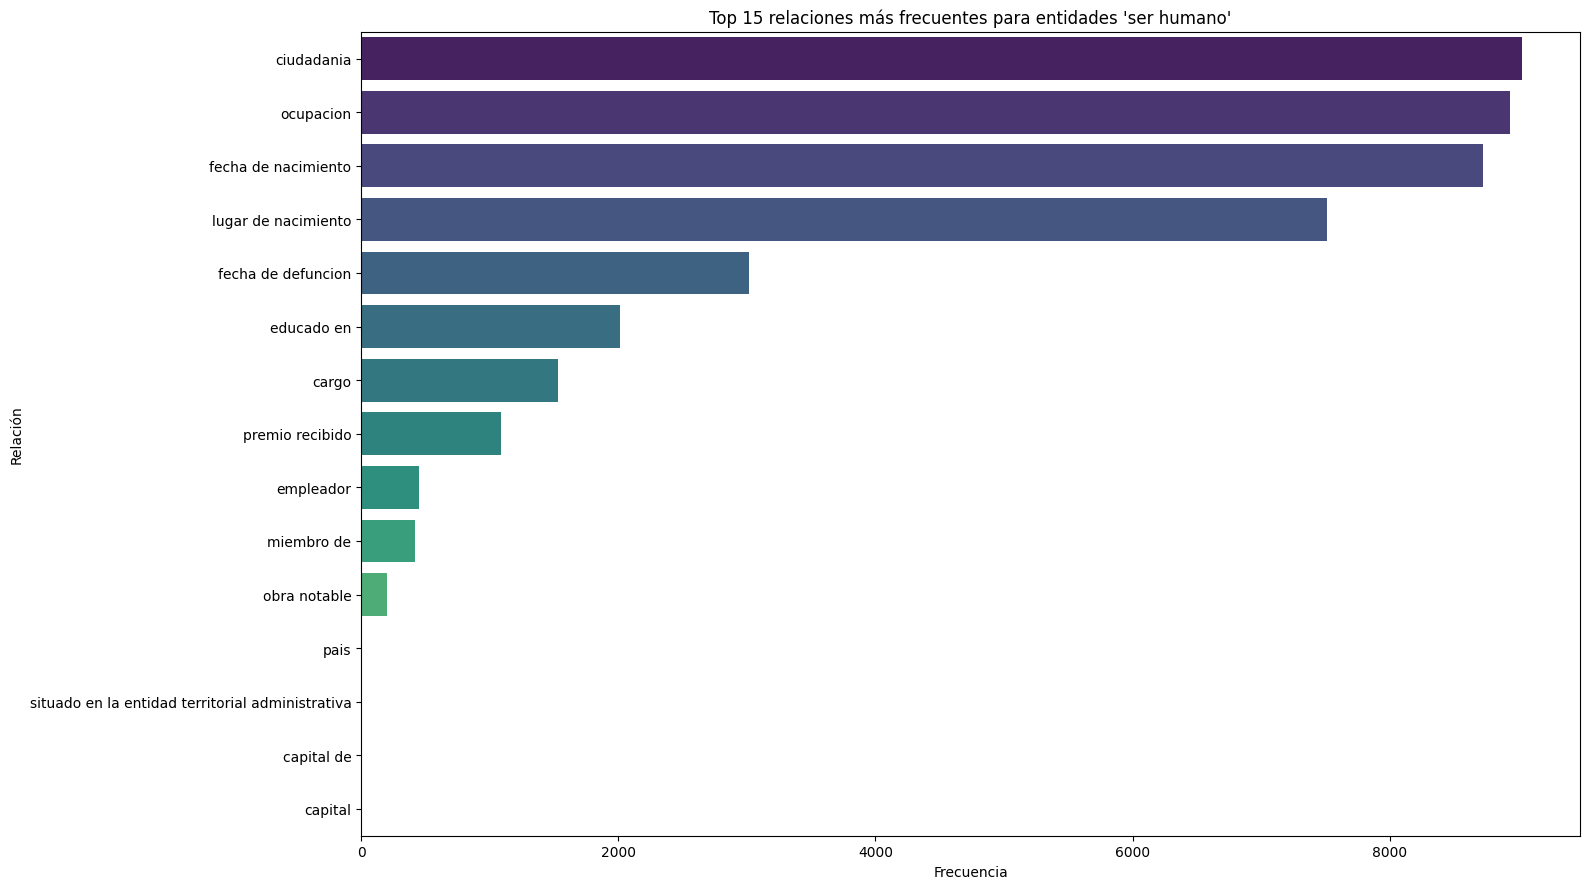

In [8]:
human_relation_counts = merged_df[merged_df['tipo_entidad'] == "ser humano"]
human_relation_counts = human_relation_counts['relacion'].value_counts().reset_index()
print(human_relation_counts[human_relation_counts['count'] >= 100]['relacion'].to_list())
plot_relations(human_relation_counts, title_suffix="entidades 'ser humano'")

['pais', 'situado en la entidad territorial administrativa', 'comparte fronteras con', 'jefe de gobierno', 'fundador', 'continente', 'ubicacion de la sede', 'capital', 'genero', 'miembro de', 'nombrado en referencia a', 'idioma de la obra o del nombre', 'idioma oficial', 'pais de origen', 'santo patron', 'autor', 'situado cerca del cuerpo de agua', 'conferido por', 'capital de', 'ciudadania', 'fecha de nacimiento', 'ubicacion', 'ocupacion']
23


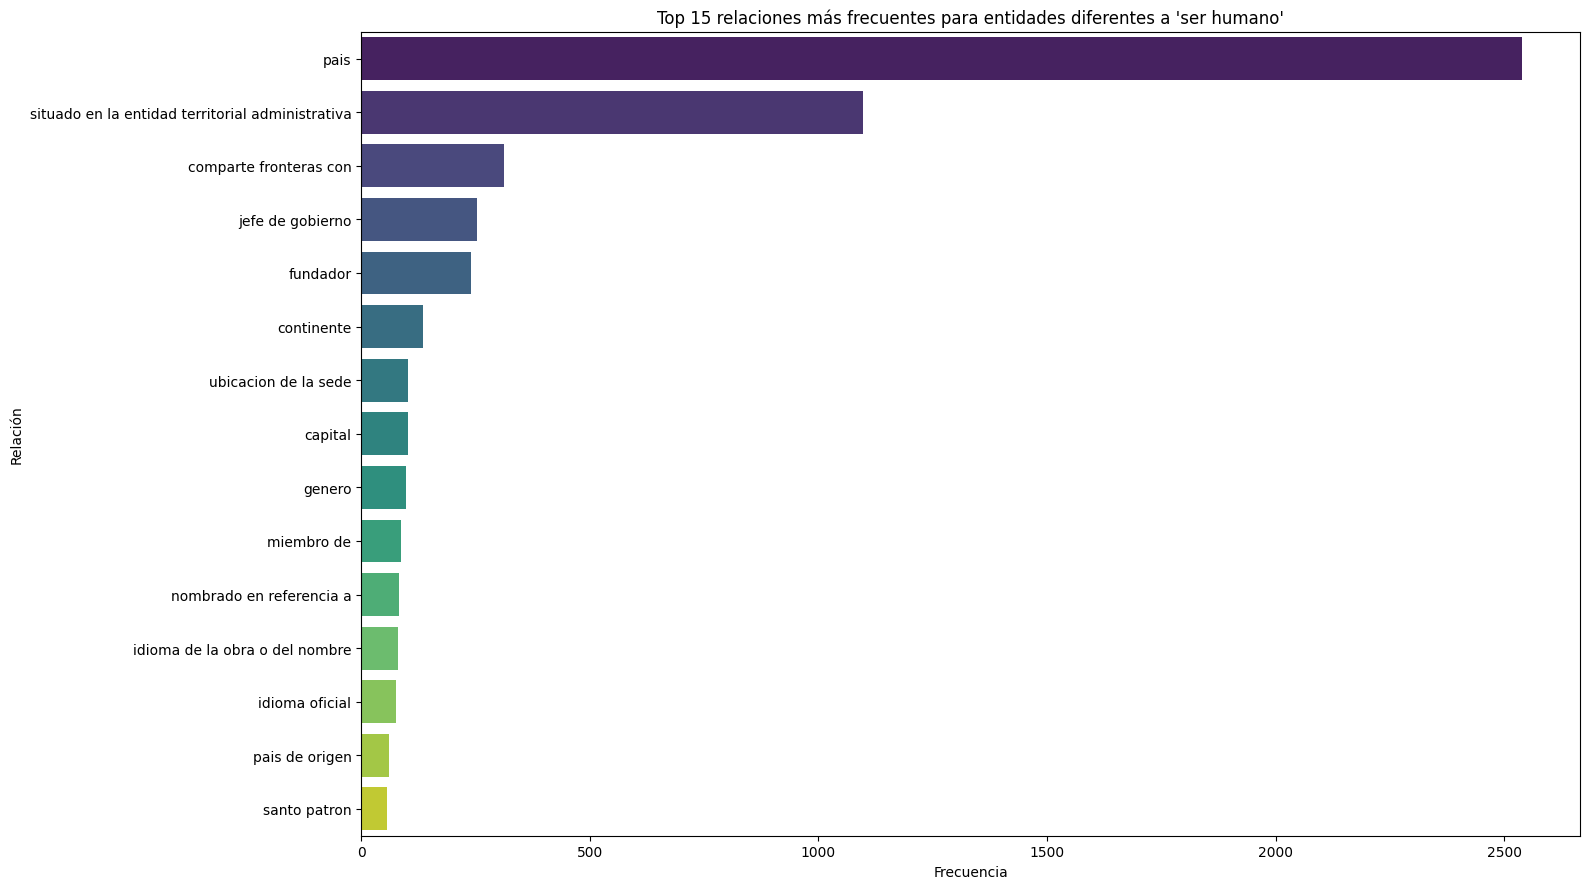

In [9]:
non_human_relation_counts = merged_df[merged_df['tipo_entidad'] != "ser humano"]
non_human_relation_counts = non_human_relation_counts['relacion'].value_counts().reset_index()
print(non_human_relation_counts[non_human_relation_counts['count'] >= 30]['relacion'].to_list())
print(len(non_human_relation_counts[non_human_relation_counts['count'] >= 30]['relacion'].to_list()))
plot_relations(non_human_relation_counts, title_suffix="entidades diferentes a 'ser humano'")

### 2) Relaciones promedio por entidad

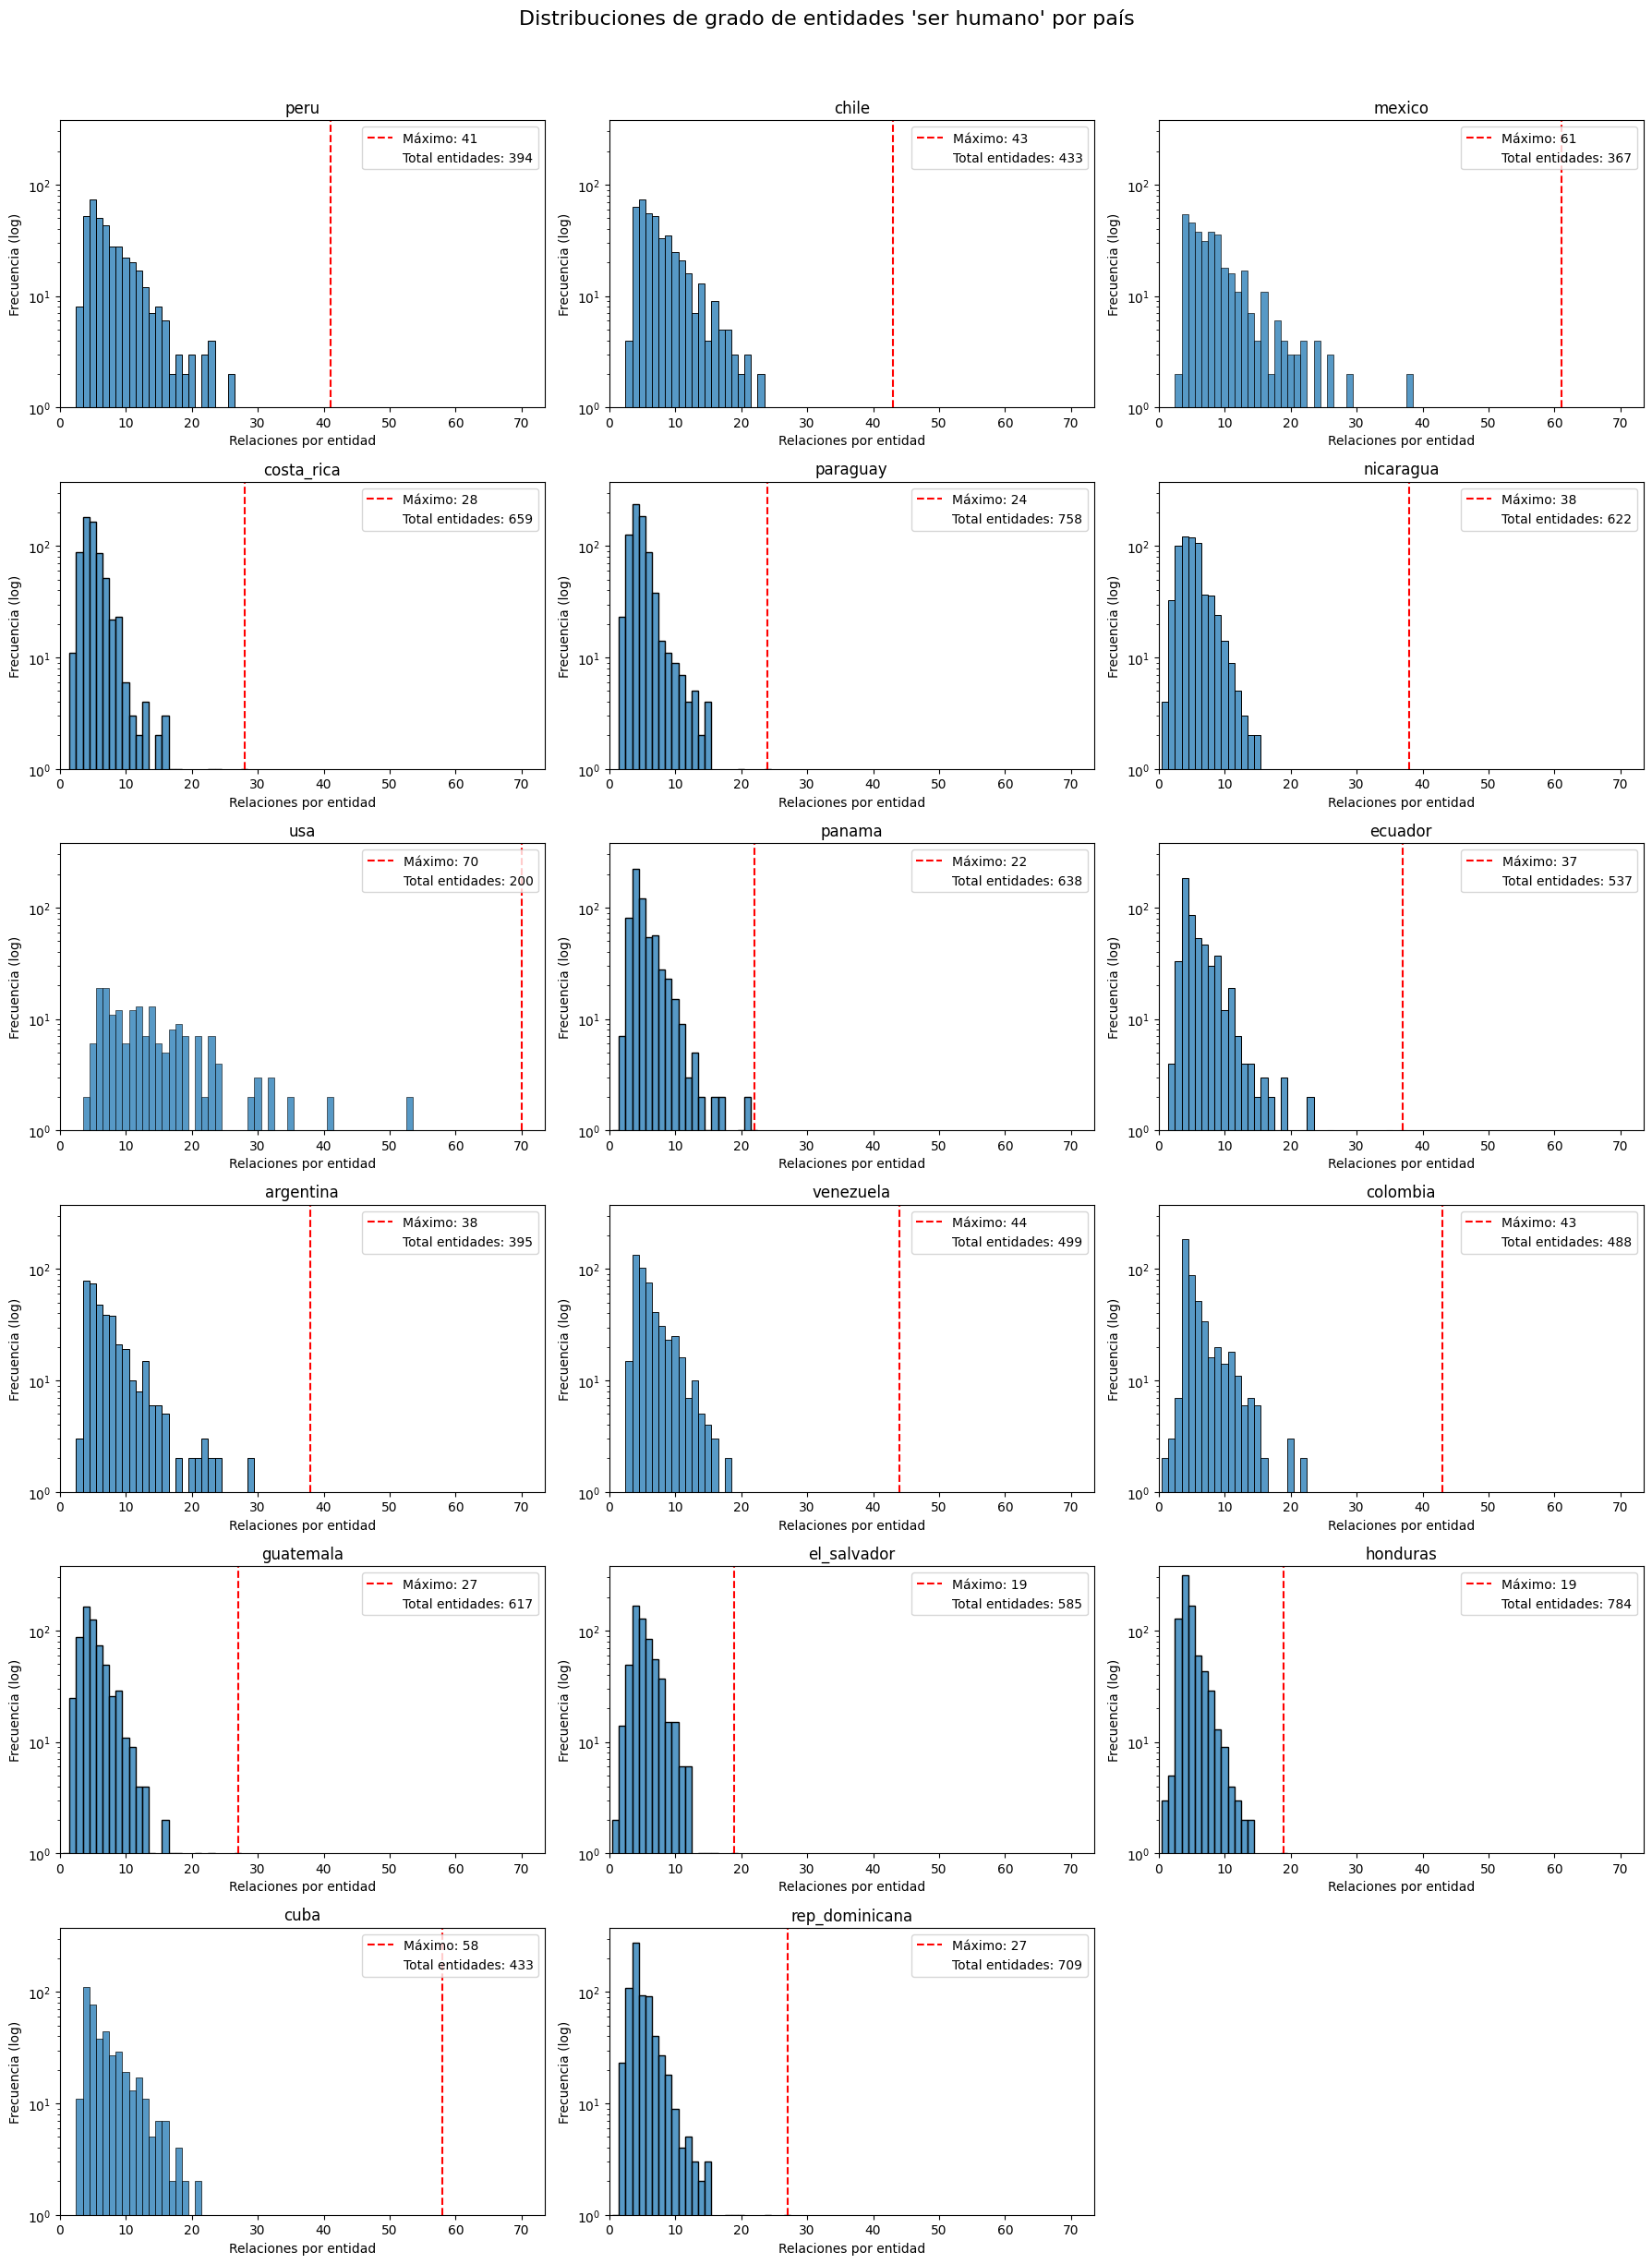

In [20]:
def plot_entity_degree_distributions(df_dict, suptitle):
    total_files = len(df_dict)
    max_x = 0
    max_y = 0
    data_dict = {}

    # Precalcula grados por archivo y máximos globales
    for country, df in df_dict.items():
        entity_degrees = df['entidad'].value_counts()
        data_dict[country] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols) if total_files > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, country in enumerate(df_dict.keys()):
        series = len(data_dict[country])
        max_val = max(data_dict[country])
        sns.histplot(data_dict[country], bins=range(0, max_x + 2), kde=False, ax=axes[i], discrete=True,)
        axes[i].axvline(x=max_val, color='r', linestyle='--', linewidth=1.5, label='Media')
        axes[i].legend([f'Total entidades: {series}'], loc='upper right')
        axes[i].set_xmargin(0)
        axes[i].set_xlim(0, max_x * 1.05)
        axes[i].set_yscale('log')
        axes[i].set_ylim(1, max_y * 1.2)
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(country.replace('.csv', ''))
        total_handle = Patch(facecolor='none', edgecolor='none',
                            label=f'Total entidades: {series}')

        axes[i].legend(handles=[Line2D([], [], color='r', linestyle='--', label=f'Máximo: {max_val}'), total_handle], loc='upper right')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(suptitle, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
plot_entity_degree_distributions(entidades_humanas_por_pais, "Distribuciones de grado de entidades 'ser humano' por país")

In [21]:
# Muchas relaciones poco relevantes
df_cuba = entidades_humanas_por_pais['cuba']
df_cuba[df_cuba['entidad'] == 'Fidel Castro'].tail(10)

,entidad,relacion,objeto,source_file,tipo_entidad
2999,Fidel Castro,Premio recibido,collar de la Orden del León Blanco,cuba,ser humano
3000,Fidel Castro,Premio recibido,Emblema de la República,cuba,ser humano
3001,Fidel Castro,Premio recibido,"Orden del Príncipe Yaroslav el Sabio, 1° grado",cuba,ser humano
3002,Fidel Castro,Premio recibido,Orden al Mérito de primera clase,cuba,ser humano
3003,Fidel Castro,Premio recibido,Banda de la Orden Mexicana del Águila Azteca,cuba,ser humano
3004,Fidel Castro,Premio recibido,doctor honoris causa de la Universidad Naciona...,cuba,ser humano
3005,Fidel Castro,Premio recibido,Order of the Yugoslavian Great Star,cuba,ser humano
3006,Fidel Castro,Premio recibido,Q109986273,cuba,ser humano
3007,Fidel Castro,Premio recibido,Grand Star of People's Friendship,cuba,ser humano
3008,Fidel Castro,Premio recibido,"Order of Eduardo Mondlane, 1st class",cuba,ser humano


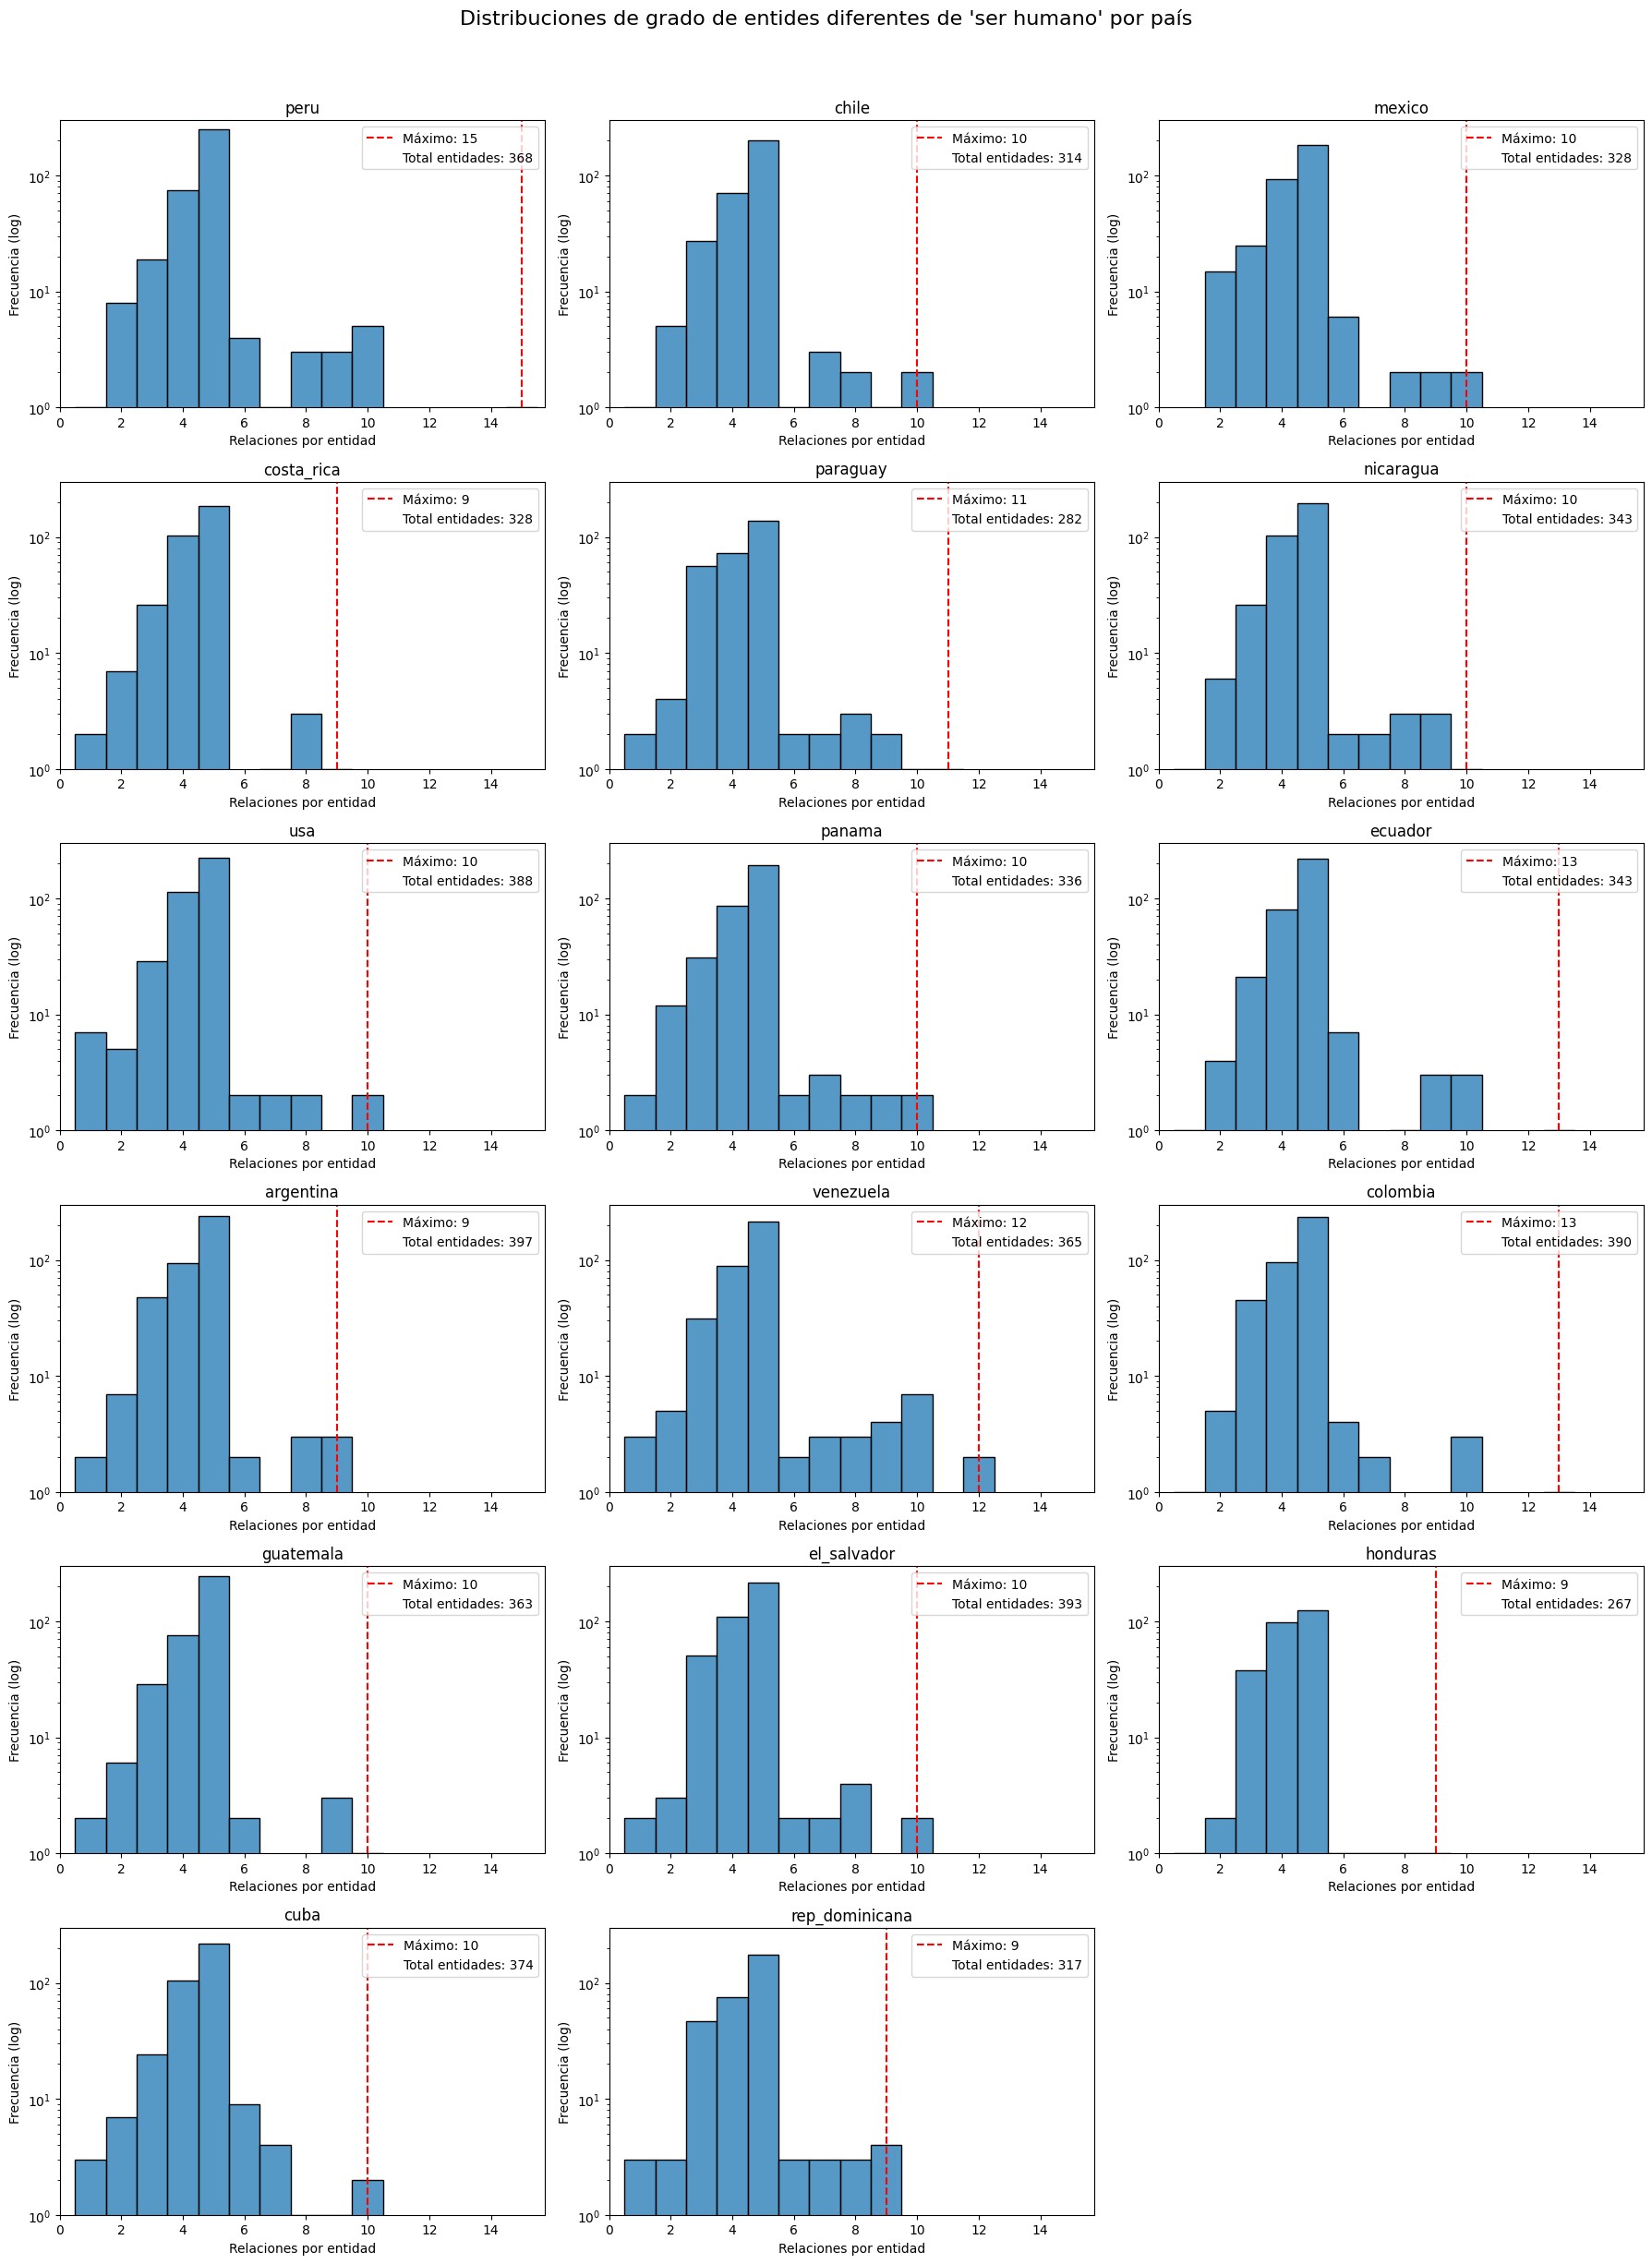

In [22]:
plot_entity_degree_distributions(entidades_no_humanas_por_pais, "Distribuciones de grado de entides diferentes de 'ser humano' por país")

In [23]:
df_hon = entidades_no_humanas_por_pais['el_salvador']
df_hon[df_hon['entidad'] == "España"]

,entidad,relacion,objeto,source_file,tipo_entidad
367,España,jefe de gobierno,Pedro Sánchez,el_salvador,página de desambiguación de Wikimedia
368,España,continente,Europa,el_salvador,página de desambiguación de Wikimedia
369,España,instancia de,país,el_salvador,página de desambiguación de Wikimedia
370,España,instancia de,Estado nación,el_salvador,página de desambiguación de Wikimedia
371,España,instancia de,reino,el_salvador,página de desambiguación de Wikimedia
1327,España,punto más alto,Teide,el_salvador,página de desambiguación de Wikimedia
1328,España,situado en la entidad geográfica,península ibérica,el_salvador,página de desambiguación de Wikimedia
1329,España,evento significativo,guerra civil española,el_salvador,página de desambiguación de Wikimedia
1330,España,evento significativo,Reconquista,el_salvador,página de desambiguación de Wikimedia
1331,España,evento significativo,guerra de la Independencia española,el_salvador,página de desambiguación de Wikimedia


## Conclusiones

* ⁠Las entidades que son “personas” en general solo ocupan 11 relaciones (fecha de nacimiento, defunción, ocupación, etc.) Las demás son muy pocas. Ahi en la reu muestro el grafico

* Para las entidades que son no persona hay mucha más variabilidad, lo que hace sentido

* Hay que tener cuidado con propiedades como los premios. Por ejemplo, Fidel castro tiene 58 tripletas, y unas 30 son premios. Vale la pena filtrarlos, y dejar los más importantes (e.g. nobel de la paz obvio que si, pero premio de Yugoslavia... quiza no)

* ⁠tambien filtré los datos sacando cosas como entidades que se pusieron con QID en vez de nombre, y relaciones inutiles (como uso horario). Quizá revisar más relaciones inútiles y objetos inútiles. Guarde los datos en Datasets/filtered_data

* lista de interés para el proyecto Wikimedia son 28 en todo el dataset. Me tinca revisarlas a mano. Otras a ver son "categoría principal del tema"

* FInalmente, mencionar
